# Рождения и независимые смерти
Дополнительное задание 5. Каждая особь умирает с интенсивностью μ,
независимо от инфекции. Рождения образуют пуассоновский поток постоянной
суммарной интенсивности μN₀. Это не рождаемость, пропорциональная текущему N.
Горизонт 400, μ∈{0.01,0.02,0.05}, пять повторов на значение.

In [1]:
using DrWatson
@quickactivate "project"
using project.SIRDES
using CSV, DataFrames, Statistics, StatsPlots
include(srcdir("experiments.jl"))
using .Experiments

In [2]:
rows=NamedTuple[]
tailrows=NamedTuple[]
fig=plot(;xlabel="Time",ylabel="I",title="Demography: one realization per mu",size=(1000,580))
for mu in [.01,.02,.05], rep in 1:5
    model,result=simulate(family="demography",mu=mu,birth_rate=mu*1000,
        T=400.0,seed=4000+rep)
    push!(rows,result)
    df=out(model)
    @assert all(df.S+df.E+df.I+df.R .== 1000 .+ df.births .- df.deaths)
    times=collect(200.0:.5:400.0)
    # Усреднение по времени, а не по неоднородно расположенным событиям.
    I_tail=mean(sample_step(df,times,:I))
    N_tail=mean(sample_step(df,times,:S)+sample_step(df,times,:I)+sample_step(df,times,:R))
    lambda=BASE_P[1]*BASE_P[2]
    Sstar=(BASE_P[3]+mu)*(1000-1)/lambda
    Istar=(mu*1000-mu*Sstar)/(BASE_P[3]+mu)
    push!(tailrows,(;mu,rep,I_tail,N_tail,Istar,Sstar,extinct=result.extinct))
    rep==1 && plot!(fig,df.t,df.I;label="mu=$(mu)",lw=1.5)
end
runs=save_table("demography-runs",DataFrame(rows))
tails=save_table("demography-tail",DataFrame(tailrows));

Row,mu,mean_tail_I,mean_tail_N,deterministic_Istar,extinction_fraction
,Float64,Float64,Float64,Float64,Float64
1,0.01,0.0,1007.85,18.4815,1.0
2,0.02,10.789,984.931,34.1141,0.8
3,0.05,64.8838,996.156,66.7667,0.0


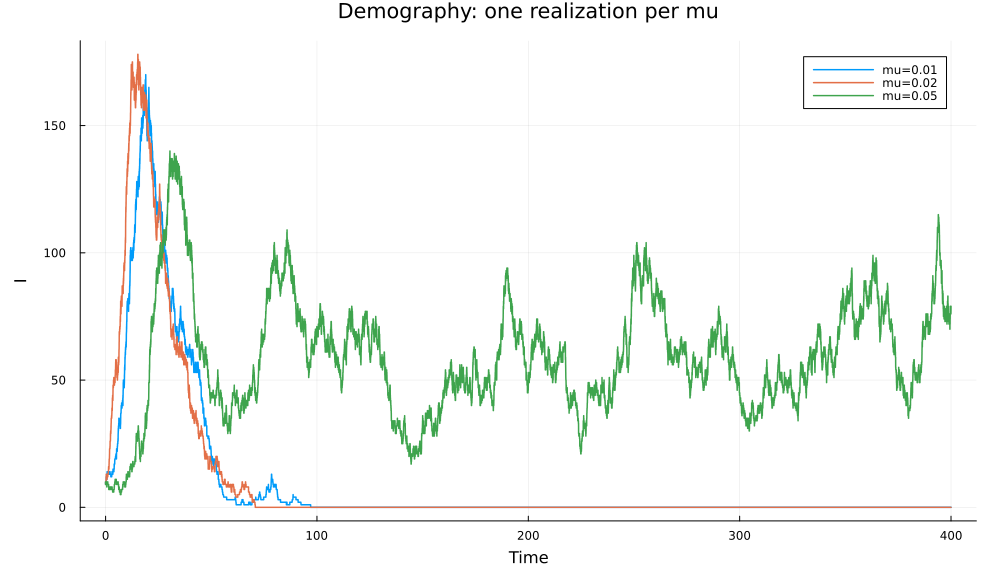

In [3]:
summary=save_table("demography-summary",combine(groupby(tails,:mu),
    :I_tail=>mean=>:mean_tail_I,:N_tail=>mean=>:mean_tail_N,
    :Istar=>first=>:deterministic_Istar,:extinct=>mean=>:extinction_fraction))
display(summary)
savefig(fig,figure_path("08-plot"))
display(fig)

## Эндемическое состояние и вымирание
I∗ получено из детерминированного приближения при N∗=1000.
При замкнутом источнике инфекции состояние I=0 поглощающее: рождения
добавляют S, но не I. Поэтому конечная стохастическая популяция может
потерять инфекцию даже при положительном детерминированном I∗.
Пять траекторий описывают опыт, но не доказывают долгосрочную устойчивость.

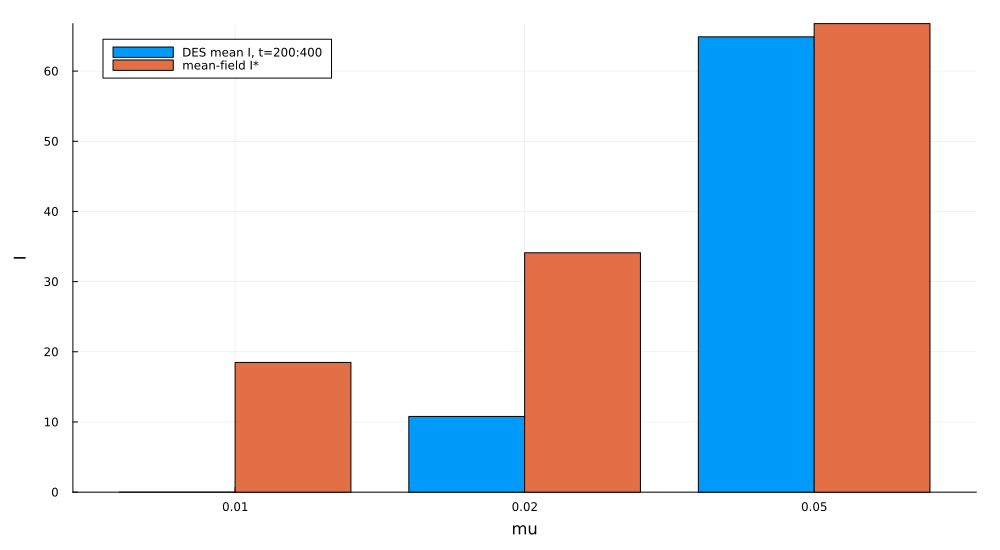

In [4]:
fig2=groupedbar(string.(summary.mu),[summary.mean_tail_I summary.deterministic_Istar];
    label=["DES mean I, t=200:400" "mean-field I*"],bar_position=:dodge,
    xlabel="mu",ylabel="I",size=(1000,550))
savefig(fig2,figure_path("09-plot"))
display(fig2)